<a href="https://colab.research.google.com/github/jane-kirina/python_for_ds_and_ml_tasks/blob/main/module_2/topic_1/HW_2_1_6_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B2%D1%96%D0%B4_%D0%B1%D0%B0%D0%B3%D0%B0%D1%82%D1%8C%D0%BE%D1%85_%D0%B7%D0%BC%D1%96%D0%BD%D0%BD%D0%B8%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

> Імпорт необхідних бібліотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

> Імпорт даних

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
car_df = pd.read_csv('drive/MyDrive/Colab Notebooks/_DLA_/module_2/data/cars.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Знайомство з даними

# Завдання 1

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [ ]:
car_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


# Завдання 2

**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [ ]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [ ]:
print(car_df.dtypes)

Car_ID                int64
Brand                object
Model                object
Year                  int64
Kilometers_Driven     int64
Fuel_Type            object
Transmission         object
Owner_Type           object
Mileage               int64
Engine                int64
Power                 int64
Seats                 int64
Price                 int64
dtype: object


> - 8 числових колонок -> `int64`
> - 5 категоріальних колонок -> `object`

In [ ]:
numeric_columns = car_df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = car_df.select_dtypes(include=['object']).columns

print(f'Числови колонки: {list(numeric_columns)}')
print(f'Категоріальні колонки: {list(categorical_columns)}')

Числови колонки: ['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']
Категоріальні колонки: ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type']


In [ ]:
# Аналіз категоріальних колонок
categories = {}

for column in categorical_columns:
    unique_vals = car_df[column].unique()
    nunique = car_df[column].nunique()

    categories[column] = {
        'name_category': column,
        'n_unique': nunique,
        'unique_values': unique_vals
    }

    print(f'Column: {column}')
    print(f'Number of unique values: {nunique}')
    print(f'Unique values: {unique_vals}\n')

Column: Brand
Number of unique values: 11
Unique values: ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']

Column: Model
Number of unique values: 58
Unique values: ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']

Column: Fuel_Type
Number of unique values: 2
Unique values: ['Petrol' 'Diesel']

Column: Transmission
Number of unique values: 2
Unique values: ['Manual' 'Automatic']

Column: Owner_Type
Number of unique values: 3
Unique values: ['First' 'Second' 'Third']



In [ ]:
# Класифікація категоріальних колонок
binary_column = []
nominal_column = []
ordinal_column = []

for column, info in categories.items():
    if info['n_unique'] == 2:
        binary_column.append(column)
    elif column == 'Owner_Type':
        ordinal_column.append(column)
    else:
        nominal_column.append(column)

> Мультикатегоріальні без порядку: `Brand`, `Model`
>
> Мультикатегоріальні з порядком: `Owner_Type`
>
> Бінарні:`Fuel_Type`, `Transmission`

In [ ]:
print(f'Кількість числових колонок: {len(numeric_columns)}')
print(f'Кількість категоріальних колонок: {len(categorical_columns)}')

print(f'Бінарні категоріальні колонки: {binary_column}')
print(f'Мультикатегоріальні без порядку: {nominal_column}')
print(f'Мультикатегоріальні з порядком: {ordinal_column}')

Кількість числових колонок: 8
Кількість категоріальних колонок: 5
Бінарні категоріальні колонки: ['Fuel_Type', 'Transmission']
Мультикатегоріальні без порядку: ['Brand', 'Model']
Мультикатегоріальні з порядком: ['Owner_Type']


У наборі даних 8 числових та 5 категоріальних колонок
Серед категоріальних колонок:
- 2 бінарні: `Fuel_Type`, `Transmission`
- 2 мультикатегоріальні без порядку: `Brand`, `Model`
- 1 мультикатегоріальна з порядком: `Owner_Type`, для якої можна встановити порядок значень $First < Second < Third$

# Завдання 3

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [ ]:
X = car_df.drop(columns=['Price'])
y = car_df['Price']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=12)

print('Розміри вибірок:')
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

Розміри вибірок:
X_train: (80, 12)
X_test: (20, 12)
y_train: (80,)
y_test: (20,)


# Завдання 4


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

## Task 1
> Закодуйте колонки з бінарними значеннями Fuel_Type і Transmission так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці

In [ ]:
def encode_binary_column(X_train, X_test, column):
    majority = X_train[column].value_counts().idxmax()

    X_train[column + '_Code'] = (X_train[column] == majority).astype(int)
    X_test[column + '_Code']  = (X_test[column]  == majority).astype(int)

    return majority

fuel_major = encode_binary_column(X_train, X_test, 'Fuel_Type')
trans_major = encode_binary_column(X_train, X_test, 'Transmission')

print("`Fuel_Type` значення 1 = ", fuel_major)
print("`Transmission` значення 1 = ", trans_major)


`Fuel_Type` значення 1 =  Petrol
`Transmission` значення 1 =  Automatic


## Task 2
> Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`

In [ ]:
# handle_unknown='ignore' -> якщо будуть невідоми бренди в test set
# sparse_output=False -> return numpy array
one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# fit тільки на train
one_hot.fit(X_train[['Brand']])

# але transform на train та test
brand_train = one_hot.transform(X_train[['Brand']])
brand_test  = one_hot.transform(X_test[['Brand']])

# назви нових колонок
brand_cols = one_hot.get_feature_names_out(['Brand'])

# додаємо в датафрейми
X_train[brand_cols] = brand_train
X_test[brand_cols]  = brand_test


## Task 3
>  Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

`OrdinalEncoder` перетворює категорії в упорядковані числа:
- 'First' → 0
- 'Second' → 1
- 'Third' → 2

Так як порядок задається через `categories`, модель "розуміє", що `Second > First` і `Third > Second`

Якщо у тесті з’явиться категорія, якої нема в списку, `OrdinalEncoder` дасть помилку (для цого можно використати `handle_unknown` параметр)

## Task +
>  Колонка Model містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

В теорії, можно використовувати частоту появи тих чи інших моделей для кодування. Якщо робити в цьому напрямі, тоді є наступні варіанти:
1. Зробити у вигляді бінарної категорії: 1 - 'топ 3 найпопулярниших моделей', 0 - 'інші'
2. Бінінг за частотою: 'very_common', 'common', 'rare', 'very_rare'
3. Залишити тільки 3-5 найпоширених моделей, та інши позначити як 'other'
4. (Можливий варіант для більш детального розподілу)
Групування по типу брендів або ціни. Розділити на 'преміум','середньій клас' та 'бюджет'

In [ ]:
X_train['Model'].value_counts()

,count
Model,
Altroz,3
Mustang,3
C-Class,3
T-Roc,2
A5,2
Q7,2
A3,2
XUV300,2
A6,2


Колонка Model має багато унікальних значень при невеликій кількості даних, тому one-hot кодування створить забагато ознак і може призвести до переобучення. Бінінг за частотою не має сенсу, бо майже всі значення мають однакову малу частоту, 2-3 приклада

Тому групуємо `Model` до 4 категорій: 3 найчастіші моделі та групу `Other` для решти

In [ ]:
top_n = 3
top_models = X_train['Model'].value_counts().head(top_n).index

X_train['Model_group'] = np.where(X_train['Model'].isin(top_models), X_train['Model'], 'Other')
X_test['Model_group']  = np.where(X_test['Model'].isin(top_models), X_test['Model'], 'Other')

print('Groups:', X_train['Model_group'].value_counts())
print('Unique groups:', X_train['Model_group'].nunique())

Groups: Model_group
Other      71
C-Class     3
Altroz      3
Mustang     3
Name: count, dtype: int64
Unique groups: 4


Наступний код як доп, щоб припрати текстові кололки, які ми вже закодували(окрім `Model`, бо в нього баато унікальних значень)

In [ ]:
'''
drop_cols = ['Fuel_Type', 'Transmission', 'Brand', 'Owner_Type']

X_train_model = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_test_model  = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])
'''

"\ndrop_cols = ['Fuel_Type', 'Transmission', 'Brand', 'Owner_Type']\n\nX_train_model = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])\nX_test_model  = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])\n"

## Result

In [ ]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes,Model_group
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Other


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes,Model_group
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Other
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other


(None, None)

# Завдання 5

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

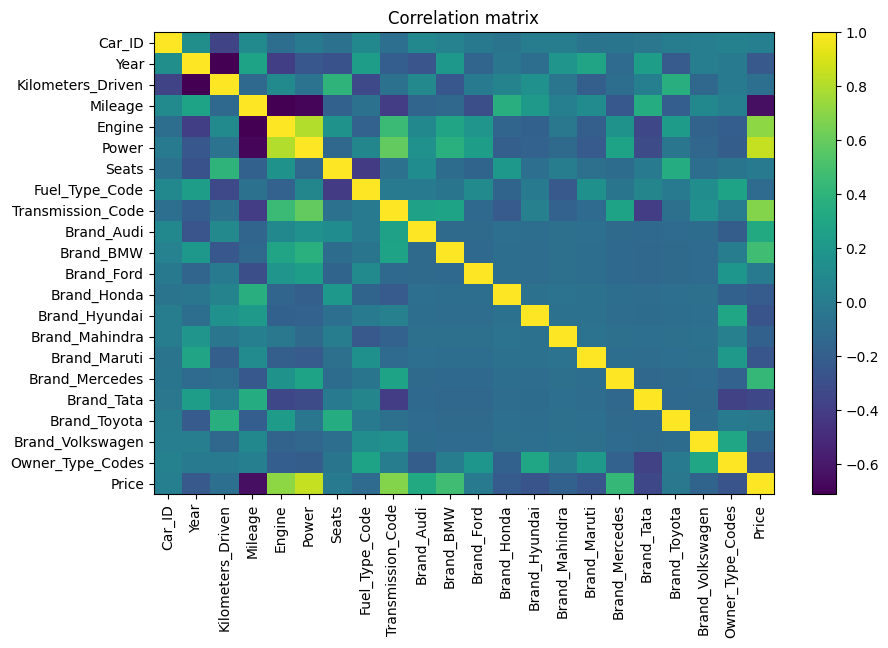

In [ ]:
# матриця кореляції
X_train_num = X_train.select_dtypes(include='number')
corr_matrix = pd.concat([X_train_num, y_train], axis=1).corr(numeric_only=True)

plt.figure(figsize=(10, 6))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.title('Correlation matrix')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.show()

In [ ]:
target_corr = corr_matrix['Price'].drop('Price')  # кореляція з ціллю без самої цілі
strong_corr = target_corr[target_corr.abs() > 0.5].sort_values(key=lambda s: s.abs(), ascending=False)

print('Колонки з |corr| > 0.5:')
print(strong_corr)
print(f'За матрицею кореляції найбільш пов’язані з цільовою змінною (|corr| > 0.5) такі ознаки: {strong_corr.index.tolist()}')


Колонки з |corr| > 0.5:
Power                0.849137
Engine               0.710561
Transmission_Code    0.680731
Mileage             -0.638404
Name: Price, dtype: float64
За матрицею кореляції найбільш пов’язані з цільовою змінною (|corr| > 0.5) такі ознаки: ['Power', 'Engine', 'Transmission_Code', 'Mileage']


In [ ]:
strong_corr

,Price
Power,0.849137
Engine,0.710561
Transmission_Code,0.680731
Mileage,-0.638404


In [ ]:
df = pd.concat([X_train_num, y_train.rename('Price')], axis=1)

In [ ]:
df

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes,Price
83,84,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1600000
55,56,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2600000
26,27,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3200000
54,55,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,650000
19,20,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,2020,30000,23,1248,74,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,600000
2,3,2017,20000,10,4951,395,4,1,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2500000
6,7,2018,45000,15,2179,140,7,0,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,900000
27,28,2019,22000,18,1995,187,5,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2800000


**Висновок**: за матрицею кореляції найбільш пов’язані з цільовою змінною 'Power', 'Engine', 'Transmission_Code', 'Mileage'
- Позитивна кореляція - при зростанні ознаки ціль зростає
- Негативна кореляція - при зростанні ознаки ціль зменшується

Чим більша потужність (Power) і об’єм/параметри двигуна (Engine) — тим вища ціна авто
`Mileage` має негативну кореляцію: чим вищий `mileage` — тим нижча ціна
`Transmission_Code` має позитивну кореляцію з ціною, тобто тип трансмісії впливає на ціну

# Завдання 6

**Завдання 6**. Тренуємо лінійну регресію.

0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

## Task 0
Видаліть усі НЕчислові колонки з X_train, X_test, якщо ще цього незробили

In [ ]:
# X_train_num = X_train.select_dtypes(include='number') # вже існує DELETE
X_test_num  = X_test.select_dtypes(include="number").copy()

print(X_train_num.shape, X_test_num.shape)

(80, 21) (20, 21)


In [ ]:
X_train_num.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes
83,84,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
X_test_num.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes
17,18,2016,38000,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,2019,26000,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,2020,18000,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,2019,26000,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


## Task 1
Натренуйте лінійну регресую з sklearn на усіх числових данихтренувального набору X_train

In [ ]:
lr = LinearRegression()
lr.fit(X_train_num, y_train)

y_pred_train = lr.predict(X_train_num)
y_pred_test  = lr.predict(X_test_num)

## Task 2
Зробіть передбачення на X_train, X_test. Знайдіть і виведіть rootmean squared error відхилення передбачення від справжніх значеньцільової змінної


In [ ]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f'RMSE train: {rmse_train:.2f}')
print(f'RMSE test : {rmse_test:.2f}')

RMSE train: 210293.58
RMSE test : 258181.56


## Task 3
Побудуйте графік розсіювання передбачень проти реальних данихцільової змінної для тренувального і тестувального наборів даних.Що можете сказати про якість моделі?


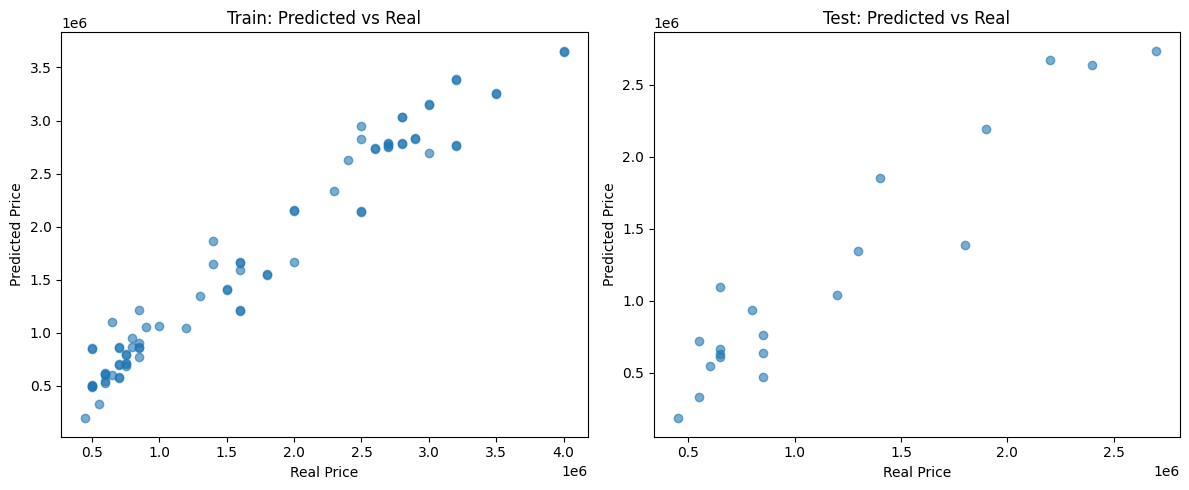

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TRAIN
axes[0].scatter(y_train, y_pred_train, alpha=0.6)
axes[0].set_title('Train: Predicted vs Real')
axes[0].set_xlabel('Real Price')
axes[0].set_ylabel('Predicted Price')

# TEST
axes[1].scatter(y_test, y_pred_test, alpha=0.6)
axes[1].set_title('Test: Predicted vs Real')
axes[1].set_xlabel('Real Price')
axes[1].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()


**Висновок**: Є чіткий позитивний тренд: коли реальна ціна більша — прогноз теж більший, але точки не лягають щільно в діагональ, розкид помітний -> помилка велика. Лінійна регресія відтворює загальний тренд ціни, однак має помітний розкид прогнозів і гіршу якість на тестових даних:
- RMSE train: $210293.58$
- RMSE test : $258181.56$
- `RMSE test > RMSE train`

Цео свідчить про обмежену точність та можливі ефекти переобучення або недостатніх ознак

# Завдання 7

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [ ]:
# Робимо копію числових колонок
X_train_num = X_train.select_dtypes(include="number").copy()
X_test_num  = X_test.select_dtypes(include="number").copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num) # fit тільки на train
X_test_scaled  = scaler.transform(X_test_num) # тільки transform на test

lr_2 = LinearRegression()
lr_2.fit(X_train_scaled, y_train)

coefs = pd.Series(lr_2.coef_, index=X_train_num.columns).sort_values(key=lambda s: s.abs(), ascending=False)
coefs.head()

,0
Power,496769.214899
Brand_Mercedes,210048.781148
Brand_BMW,208407.313783
Brand_Audi,205600.147769
Fuel_Type_Code,-183848.018909


In [ ]:
top = coefs.head(10)
print(top)

Power                496769.214899
Brand_Mercedes       210048.781148
Brand_BMW            208407.313783
Brand_Audi           205600.147769
Fuel_Type_Code      -183848.018909
Brand_Hyundai       -152304.863911
Brand_Mahindra      -140945.162904
Mileage             -131715.512030
Brand_Ford          -118209.450311
Transmission_Code    116693.768206
dtype: float64


Після масштабування найвпливовіші ознаки за |coef|:
- `Power` - позитивний вплив
- one-hot ознаки брендів
  - Mercedes, BMW, Audi - позитивний вплив
  - Hyundai, Mahindra, Ford - негативний вплив
- `Fuel_Type_Code` - негативний вплив
- `Transmission_Code` - позитивний вплив
- `Kilometers_Driven` - негативний вплив
- `Mileage` - негативний вплив

Ознаки переважно логічно впливають на ціну. Такі ознаки як `Kilometers_Driven` і `Mileage` мають негативні коефіцієнти, що загалом відповідає очікуванню 'більше пробігу/зношеності -> нижча ціна' та  такі преміум-бренди як Mercedes, BMW та Audi мають позитивний вплив -> підвищують ціну

# Завдання 8

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [ ]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_num.columns, index=X_train_num.index)
X_train_sm = sm.add_constant(X_train_scaled_df)
ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     68.35
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           2.01e-33
Time:                        14:15:12   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2230.
Df Residuals:                      59   BIC:                             2280.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.74e+0

In [ ]:
p_values = ols_model.pvalues
significant = p_values[p_values < 0.05].index.tolist()
significant = [c for c in significant if c != 'const']

print(f'Significant features (p < 0.05): {significant}')
print(p_values[p_values < 0.05].sort_values())

Significant features (p < 0.05): ['Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Volkswagen']
const                3.734558e-55
Brand_Audi           7.485851e-09
Brand_Mercedes       9.320195e-09
Power                1.343837e-08
Brand_BMW            1.669757e-08
Brand_Hyundai        2.204650e-06
Brand_Mahindra       1.354686e-05
Fuel_Type_Code       1.639420e-04
Brand_Maruti         2.875539e-04
Brand_Ford           8.736558e-04
Brand_Volkswagen     2.993263e-03
Transmission_Code    1.022962e-02
Mileage              2.760048e-02
dtype: float64


Значущі ознаки (p < 0.05):
- Mileage
- Power
- Fuel_Type_Code
- Transmission_Code
- Brand_Audi
- Brand_BMW
- Brand_Ford
- Brand_Hyundai
- Brand_Mahindra
- Brand_Maruti
- Brand_Mercedes
- Brand_Volkswagen

Ці змінні мають коефіцієнти, які статистично відрізняються від нуля
Але `Year`, `Kilometers_Driven`, `Engine`, `Seats`, `Owner_Type_Codes` мають p-value > 0.05 -> не значущі в цій моделі (можливо через кореляції між ознаками)

# Завдання 9

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [ ]:
# перетворюємо scaled X у DataFrame з назвами колонок
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_num.columns, index=X_train_num.index)
X_train_sig = X_train_scaled_df[significant] # беремо тільки значущі фічі
X_train_sig_sm = sm.add_constant(X_train_sig)
ols_sig = sm.OLS(y_train, X_train_sig_sm).fit()

print(ols_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           4.12e-39
Time:                        14:15:12   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.78e+0

In [ ]:
print('ALL features:')
print('R2:', round(ols_model.rsquared, 4))
print('Adj R2:', round(ols_model.rsquared_adj, 4))

print('\nONLY significant features:')
print('R2:', round(ols_sig.rsquared, 4))
print('Adj R2:', round(ols_sig.rsquared_adj, 4))


ALL features:
R2: 0.9586
Adj R2: 0.9446

ONLY significant features:
R2: 0.9514
Adj R2: 0.9427


Після залишення лише статистично значущих ознак якість моделі майже не погіршилась. Це означає, що прибрані ознаки давали мало додаткової пояснювальної сили, і спрощена модель є майже такою ж якісною, але більш компактною та інтерпретованою

# Завдання 10

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 7 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 7? Яку модель з останніх 3х завдань ви б лишили для використання?

In [ ]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_num.columns, index=X_train_num.index)

pvals = ols_model.pvalues

features_025 = pvals[(pvals < 0.25)].index
features_025 = [f for f in features_025 if f != 'const']

print('К-сть ознак p<0.25:', len(features_025))
print('Список:', features_025)

X_train_025 = sm.add_constant(X_train_scaled_df[features_025])
ols_025 = sm.OLS(y_train, X_train_025).fit()

print(ols_025.summary())


К-сть ознак p<0.25: 15
Список: ['Kilometers_Driven', 'Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Volkswagen']
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           4.85e-38
Time:                        14:15:12   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:  

Модель з відбором ознак за `p-value < 0.25` показала `R² ~ 0.958` і `Adj.R² ~ 0.948`, що майже не відрізняється від моделі на всіх ознаках за `R²`, але має вищий `Adj.R²`. Порівняно з моделлю лише зі значущими (`p < 0.05`) ознаками вона краще пояснює варіацію ціни. Тому як компроміс між якістю та простотою доцільно залишити модель з `p < 0.25`